# LeetCode #762: Prime Number of Set Bits in Binary Representation

https://leetcode.com/problems/prime-number-of-set-bits-in-binary-representation/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (isprime loop)** | $O(n \sqrt{20})$ | $O(1)$ |
| **Optimal: Bit Manipulation + Prime Mask ★** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (isprime loop)
For each number, compute popcount, then trial-divide to check primality. Since popcount $\le 20$ (as $10^6 < 2^{20}$), the primality check is $O(\sqrt{20})$ — effectively constant, but still a loop.

### Optimal: Bit Manipulation + Prime Mask ★
Pre-bake a 32-bit mask `665772` with bits set at positions 2, 3, 5, 7, 11, 13, 17, 19 (all primes $\le 20$). For each number, compute popcount, then check `(mask >> popcount) & 1` — single shift and AND, no primality loop.

**Why this is better than Brute Force:** The primality check becomes two bit operations — no trial division loop needed, even though both approaches are $O(1)$ per number.

**Constraints:**
* $1 \le$ left $\le$ right $\le 10^6$
* $0 \le$ right - left $\le 10^4$

## Solutions

### C#

In [ ]:
using System.Numerics;

public int CountPrimeSetBits(int left, int right) {
    // Bitmask with 1s at prime positions: 2,3,5,7,11,13,17,19
    // 0b10100010100010101100 = 665772
    int primeMask = 0b10100010100010101100;
    int count = 0;
    for (int n = left; n <= right; n++) {
        int bits = BitOperations.PopCount((uint)n);
        // Check if popcount is a prime via the precomputed mask
        if ((primeMask >> bits & 1) == 1) count++;
    }
    return count;
}

### Python

In [ ]:
def countPrimeSetBits(self, left: int, right: int) -> int:
    # Bitmask with 1s at prime positions 2,3,5,7,11,13,17,19
    prime_mask = 0b10100010100010101100  # = 665772
    count = 0
    for n in range(left, right + 1):
        bits = bin(n).count('1')
        # Check if popcount is prime via the precomputed mask
        if (prime_mask >> bits) & 1:
            count += 1
    return count

### Go

In [ ]:
import "math/bits"

func countPrimeSetBits(left int, right int) int {
    // Bitmask with 1s at prime positions 2,3,5,7,11,13,17,19
    primeMask := 0b10100010100010101100 // = 665772
    count := 0
    for n := left; n <= right; n++ {
        b := bits.OnesCount(uint(n))
        // Check if popcount is prime via the precomputed mask
        if (primeMask>>b)&1 == 1 {
            count++
        }
    }
    return count
}

### Rust

In [ ]:
pub fn count_prime_set_bits(left: i32, right: i32) -> i32 {
    // Bitmask with 1s at prime positions 2,3,5,7,11,13,17,19
    let prime_mask: u32 = 0b10100010100010101100; // = 665772
    (left..=right).filter(|&n| {
        let bits = (n as u32).count_ones();
        // Check if popcount is prime via the precomputed mask
        (prime_mask >> bits) & 1 == 1
    }).count() as i32
}

## Example Scenarios

**1. Common Case**
**Input:** left=6, right=10
popcount: 6→2(prime✓), 7→3(prime✓), 8→1(no), 9→2(prime✓), 10→2(prime✓). Result: **4**.

**2. Slightly Complex**
**Input:** left=10, right=15
popcount: 10→2✓, 11→3✓, 12→2✓, 13→3✓, 14→3✓, 15→4(not prime✗). Result: **5**. Note 4 is not prime.

**3. Edge Case: Time Factor**
**Input:** left=1, right=10001 (range of $10^4$ numbers)
Up to $10^4$ iterations, each doing one popcount + one bit shift. Total $O(n)$ where $n=10^4$. Using the prime mask avoids $O(n \cdot \sqrt{20})$ trial-division inner loops.

**4. Edge Case: Space Factor**
**Input:** left=$10^6 - 10^4 + 1$, right=$10^6$
All numbers near $10^6 \approx 2^{20}$; max popcount = 20. The prime_mask has bit 19 set (19 is prime), so numbers with exactly 19 or 20 set bits count if those are prime. $O(1)$ extra space throughout.

**5. Almost-Impossible but Plausible**
**Input:** left=right=524287 ($2^{19}-1$, 19 ones in binary)
popcount = 19 (prime → counted). 19 is prime, so the mask has its 19th bit set. Result: **1**. Near the $10^6$ ceiling and has the maximum plausible popcount for the given range.

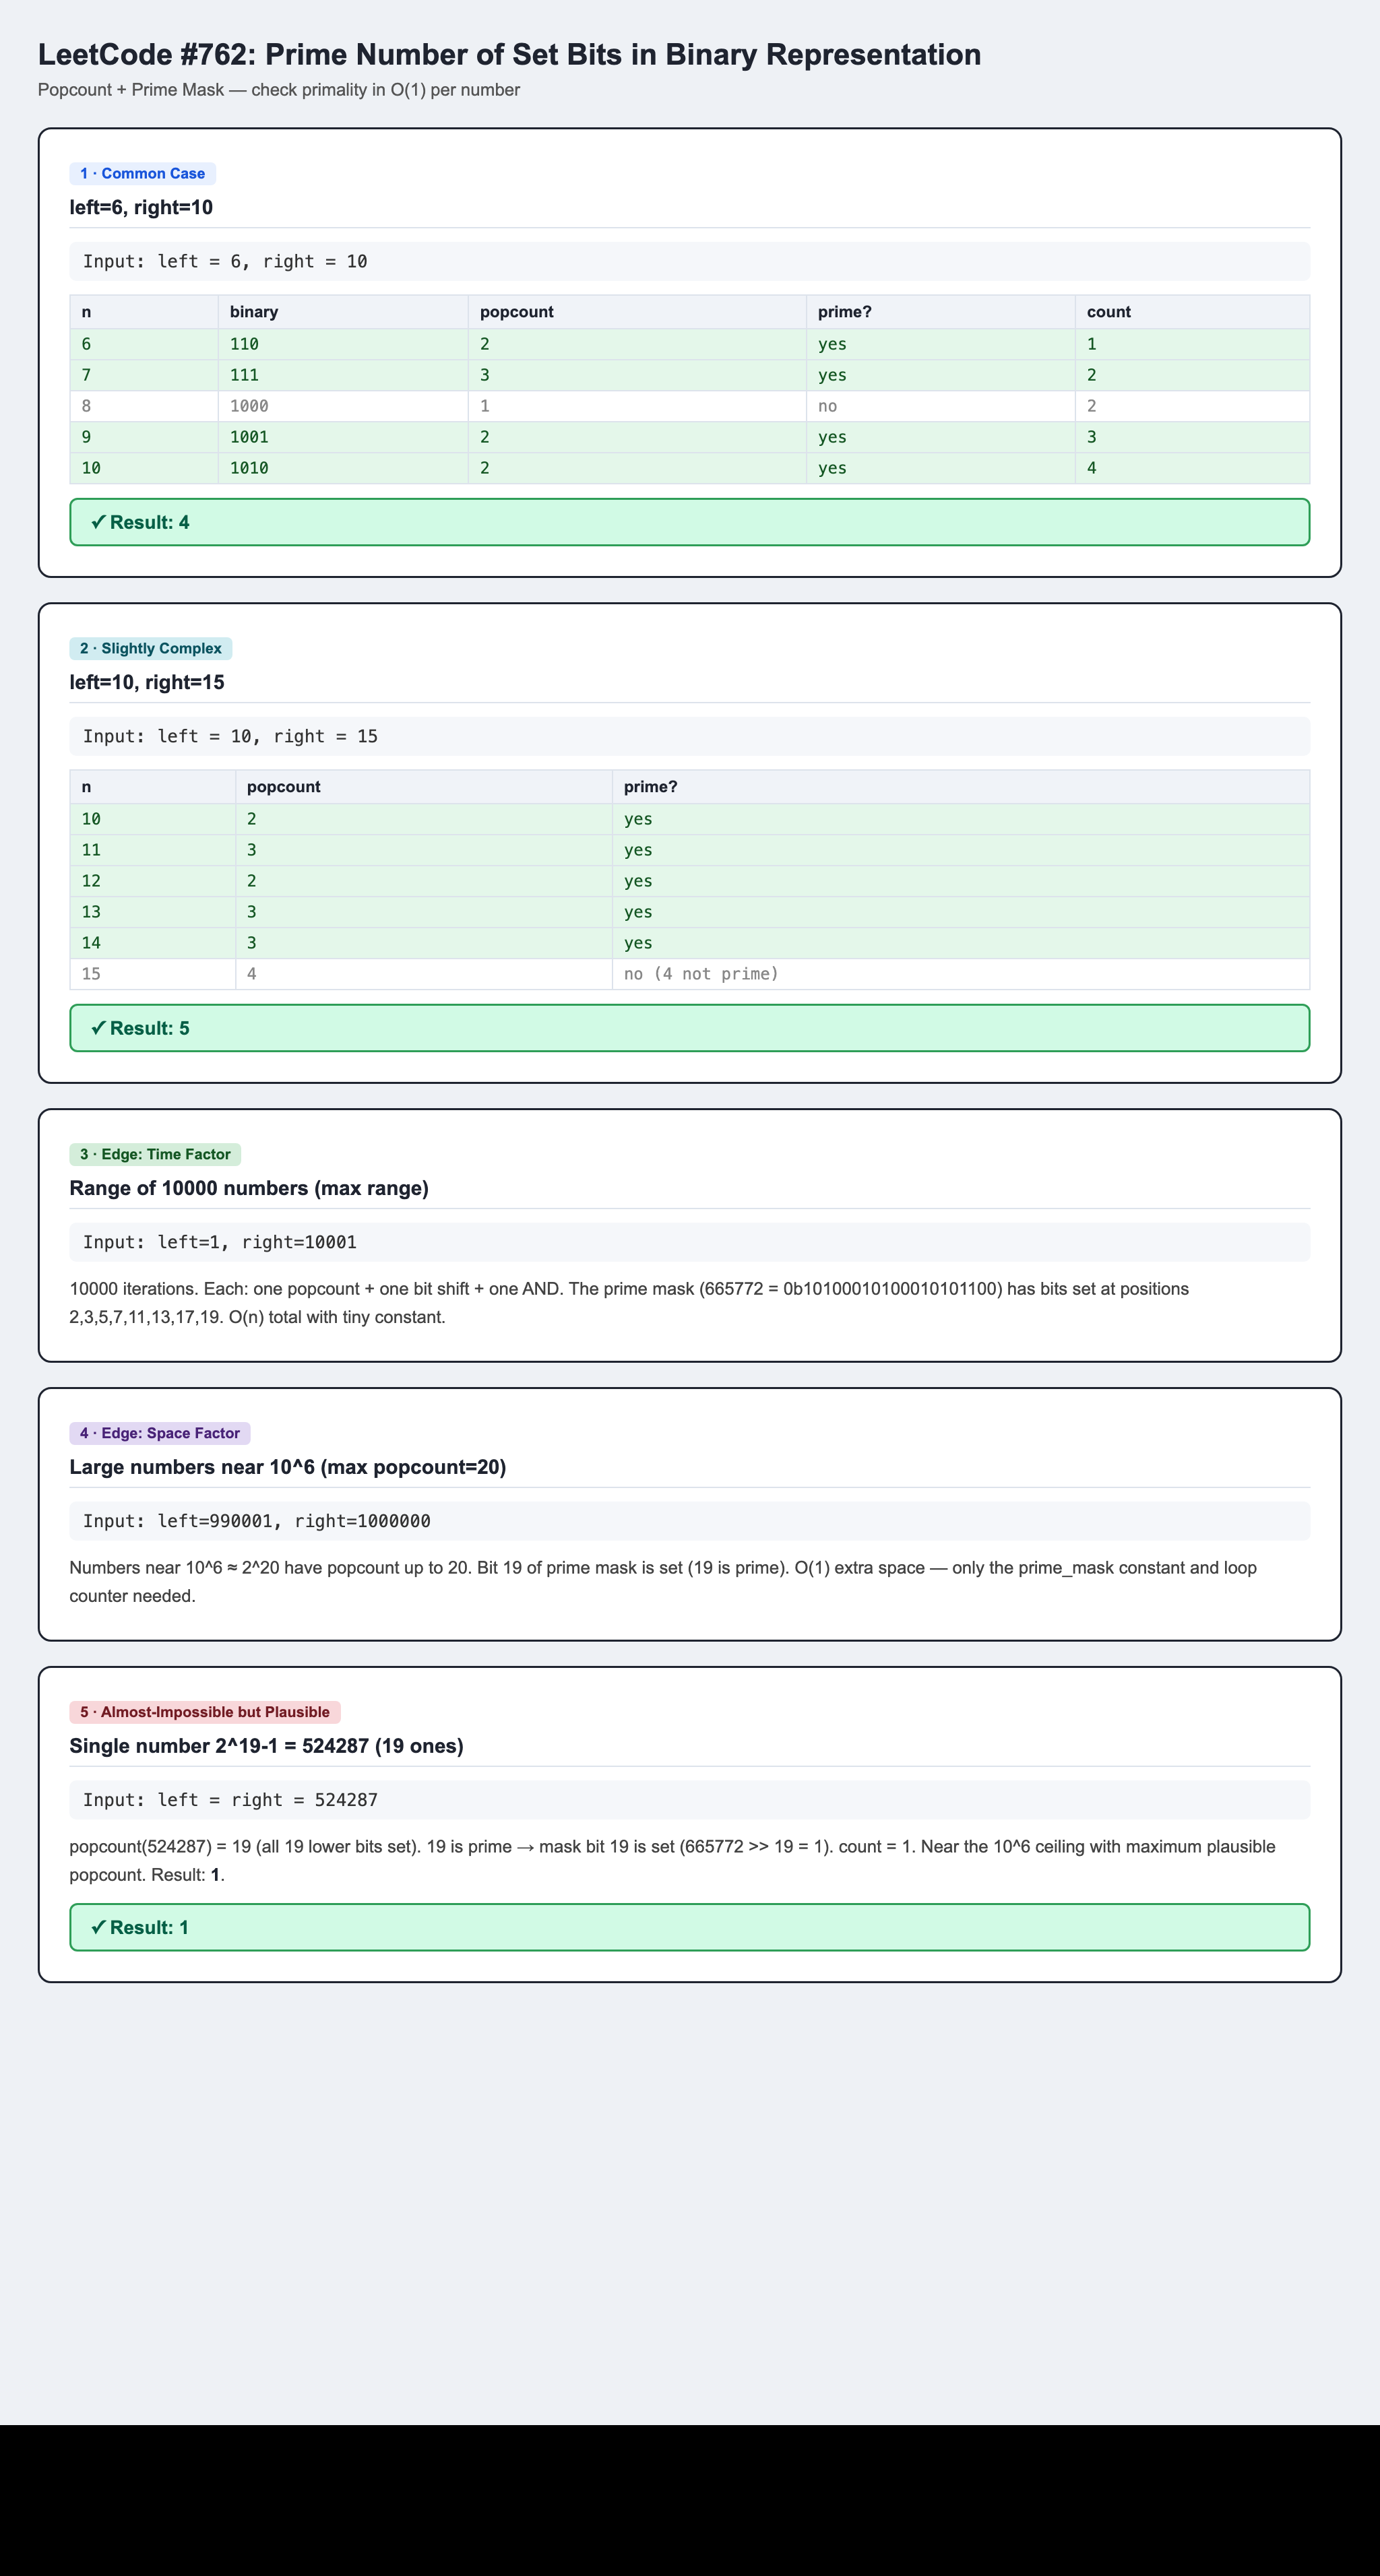